# 🌿 Plant Disease Detection using Machine Learning & Deep Learning

**Subject:** Machine Learning / Deep Learning Mini Project
**Dataset:** PlantVillage (Kaggle)

---

In this project I'm trying to detect diseases in plants from leaf images.
The idea is pretty simple — if we can train a model to look at a photo of a leaf
and tell us whether it's healthy or diseased (and which disease), that could
actually be really useful for farmers who don't have easy access to experts.

I'm using the PlantVillage dataset from Kaggle which has about 38 different
classes of plant conditions. I'll be trying out multiple ML models — KNN,
Decision Tree, Random Forest, SVM, MLP — and then also building a CNN
to see how deep learning compares. At the end there's a small UI using Gradio
so you can actually upload a leaf photo and get a prediction.

Let's go!


---
## Step 1: Setting up Kaggle and Downloading the Dataset

First things first — I need to download the dataset from Kaggle.
For this you need a `kaggle.json` API key file from your Kaggle account.
Go to kaggle.com → Account → Create API Token → upload that file when prompted below.


In [ ]:
# upload your kaggle.json here
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kanikagarg1","key":"ec6330cc85a3aa53d216973ff941e31a"}'}

In [2]:
import os
import shutil

# move kaggle.json to the right place so the kaggle CLI can find it
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle setup done!")


Kaggle setup done!


In [3]:
# download the dataset
!kaggle datasets download -d emmarex/plantdisease
print("Download complete!")


Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:05<00:00, 137MB/s] 

Download complete!


In [4]:
import zipfile

# extract it
with zipfile.ZipFile("plantdisease.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extracted successfully!")


Extracted successfully!


---
## Step 2: Exploring the Data

Let me take a quick look at what we've got — how many classes, what they look like, etc.


In [5]:
import os

data_dir = "data/PlantVillage"
classes = sorted(os.listdir(data_dir))

print(f"Total classes found: {len(classes)}")
print("\nFirst 10 classes:")
for c in classes[:10]:
    print(" -", c)


Total classes found: 15

First 10 classes:
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

IMG_SIZE = 128

# I'm limiting to 300 images per class to keep things manageable on Colab
# (otherwise loading everything would take forever and might crash RAM)
X = []
y = []

for label, folder in enumerate(classes):
    path = os.path.join(data_dir, folder)
    count = 0
    for img_name in os.listdir(path):
        if count >= 300:
            break
        try:
            img_path = os.path.join(path, img_name)
            image = cv2.imread(img_path)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X.append(image)
            y.append(label)
            count += 1
        except:
            pass  # skip any corrupted images

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"Total images loaded: {len(X)}")


X shape: (4352, 128, 128, 3)
y shape: (4352,)
Total images loaded: 4352


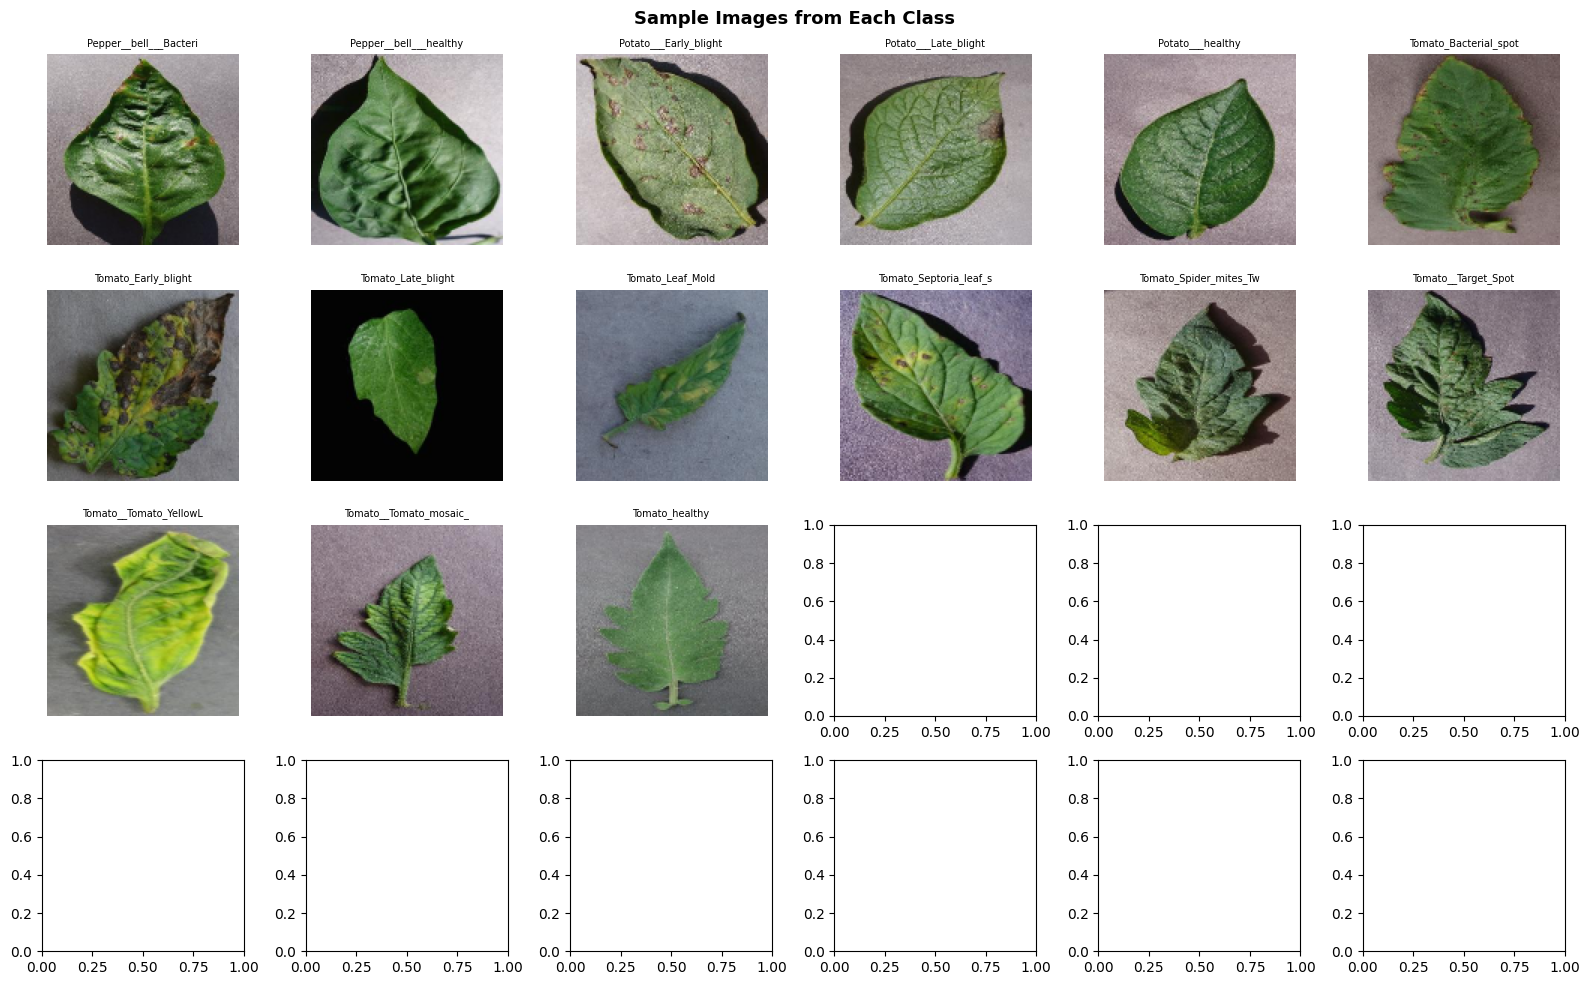

In [7]:
# let me visualise a few sample images to get a feel for the data
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
axes = axes.flatten()

for i in range(min(24, len(classes))):
    idx = np.where(y == i)[0][0]
    img_rgb = cv2.cvtColor(X[idx], cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(classes[i][:22], fontsize=7)
    axes[i].axis("off")

plt.suptitle("Sample Images from Each Class", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 3: Preprocessing for Classical ML (Normalisation + PCA)

For the traditional ML models (SVM, KNN, etc.) I can't directly feed in
raw 128×128×3 images — that would be 49,152 features per image which is way
too much. So the plan is:

1. Normalise pixel values to [0, 1]
2. Flatten each image into a 1D vector
3. Use PCA to reduce dimensions down to something reasonable (100 components)

PCA basically keeps the most "important" information and throws away the noise.


In [8]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# normalise
X_norm = X / 255.0

# flatten each image: 128x128x3 → 49152 values
X_flat = X_norm.reshape(len(X_norm), -1)
print("Flattened shape:", X_flat.shape)


Flattened shape: (4352, 49152)


After PCA: (4352, 100)


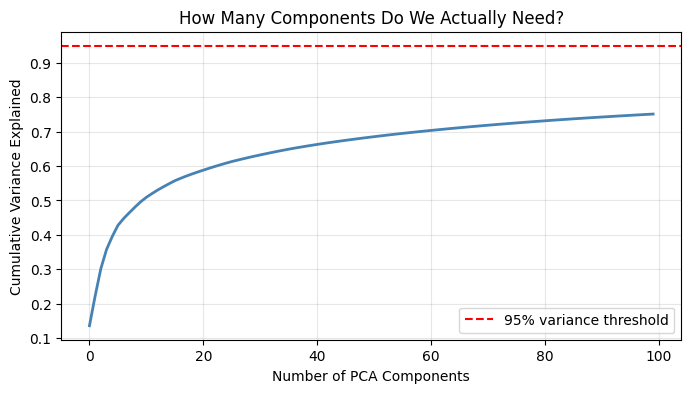

In [9]:
# applying PCA - I'll use 100 components as a starting point
pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_flat)

print("After PCA:", X_pca.shape)

# plot how much variance each component explains
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='steelblue', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("How Many Components Do We Actually Need?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [10]:
# train-test split (80-20)
# using stratify=y so each class is represented proportionally
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (3481, 100)
Test set: (871, 100)


---
## Step 4: Training Classical ML Models

Now let's train 5 different models and see how they compare.
I'll train them all on the PCA-reduced features.

Models:
- **KNN** — predicts based on nearest neighbours
- **Decision Tree** — simple tree-based rules
- **Random Forest** — ensemble of many trees
- **SVM** — finds the best separating hyperplane
- **MLP** — small neural network (fully connected)


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Training all models... this might take a few minutes")
print("=" * 50)


Training all models... this might take a few minutes


In [12]:
# KNN - I'll start with k=5 as a baseline
print("[1/5] Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test))
print(f"  Done! KNN Accuracy: {knn_acc:.4f}")


[1/5] Training KNN...
  Done! KNN Accuracy: 0.5419


In [13]:
# Decision Tree - no hypertuning yet, just default
print("[2/5] Training Decision Tree...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"  Done! Decision Tree Accuracy: {dt_acc:.4f}")


[2/5] Training Decision Tree...
  Done! Decision Tree Accuracy: 0.3513


In [14]:
# Random Forest - 200 trees, decent starting point
print("[3/5] Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"  Done! Random Forest Accuracy: {rf_acc:.4f}")


[3/5] Training Random Forest...
  Done! Random Forest Accuracy: 0.6016


In [15]:
# SVM with RBF kernel - usually works well for image features
print("[4/5] Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
print(f"  Done! SVM Accuracy: {svm_acc:.4f}")


[4/5] Training SVM...
  Done! SVM Accuracy: 0.7382


In [16]:
# MLP - a small fully connected network
print("[5/5] Training MLP...")
mlp = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=50, random_state=42)
mlp.fit(X_train, y_train)
mlp_acc = accuracy_score(y_test, mlp.predict(X_test))
print(f"  Done! MLP Accuracy: {mlp_acc:.4f}")


[5/5] Training MLP...
  Done! MLP Accuracy: 0.6923


In [17]:
# quick comparison before tuning
baseline_results = {
    "KNN":           knn_acc,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "SVM":           svm_acc,
    "MLP":           mlp_acc,
}

print("\nBaseline Results (before tuning):")
print("-" * 35)
for name, acc in sorted(baseline_results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<20} {acc:.4f}")



Baseline Results (before tuning):
-----------------------------------
  SVM                  0.7382
  MLP                  0.6923
  Random Forest        0.6016
  KNN                  0.5419
  Decision Tree        0.3513


---
## Step 5: Hyperparameter Tuning

The default parameters aren't always the best — let's do some tuning!

I'll use:
- **GridSearchCV** for KNN (small search space, can be exhaustive)
- **RandomizedSearchCV** for SVM and Random Forest (too many combos for grid search)

This will take a bit but it's worth it for better accuracy.


In [18]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# -- Tuning KNN --
print("Tuning KNN with GridSearchCV...")
knn_params = {
    'n_neighbors': [3, 5, 7, 11],
    'metric':      ['euclidean', 'manhattan', 'minkowski'],
    'weights':     ['uniform', 'distance']
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
knn_gs.fit(X_train, y_train)

best_knn = knn_gs.best_estimator_
best_knn_acc = accuracy_score(y_test, best_knn.predict(X_test))

print(f"\nBest KNN params: {knn_gs.best_params_}")
print(f"Best KNN Accuracy: {best_knn_acc:.4f}  (was {knn_acc:.4f})")


Tuning KNN with GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best KNN params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN Accuracy: 0.5465  (was 0.5419)


In [19]:
# -- Tuning SVM --
print("Tuning SVM with RandomizedSearchCV...")
svm_params = {
    'C':      [0.1, 1, 5, 10, 50],
    'gamma':  ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'poly']
}

svm_rs = RandomizedSearchCV(
    SVC(probability=True, random_state=42),
    svm_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
svm_rs.fit(X_train, y_train)

best_svm = svm_rs.best_estimator_
best_svm_acc = accuracy_score(y_test, best_svm.predict(X_test))

print(f"\nBest SVM params: {svm_rs.best_params_}")
print(f"Best SVM Accuracy: {best_svm_acc:.4f}  (was {svm_acc:.4f})")


Tuning SVM with RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best SVM params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 5}
Best SVM Accuracy: 0.7279  (was 0.7382)


In [20]:
# -- Tuning Random Forest --
print("Tuning Random Forest with RandomizedSearchCV...")
rf_params = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, 30, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_rs.fit(X_train, y_train)

best_rf = rf_rs.best_estimator_
best_rf_acc = accuracy_score(y_test, best_rf.predict(X_test))

print(f"\nBest RF params: {rf_rs.best_params_}")
print(f"Best RF Accuracy: {best_rf_acc:.4f}  (was {rf_acc:.4f})")


Tuning Random Forest with RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best RF Accuracy: 0.6096  (was 0.6016)


---
## Step 6: CNN (Convolutional Neural Network)

Okay, now for the fun part — CNNs are specifically designed for image data.
Unlike the classical models above, CNNs don't need PCA or manual feature extraction;
they learn the features themselves through convolutional filters.

My CNN has 4 convolutional blocks, each followed by batch normalisation, max pooling,
and dropout (to prevent overfitting). Then a couple of dense layers at the end.

I'm also using **data augmentation** — randomly flipping, rotating, and zooming
training images so the model generalises better.


In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.test.is_gpu_available() if hasattr(tf.test, 'is_gpu_available') else len(tf.config.list_physical_devices('GPU')) > 0)


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


TensorFlow version: 2.19.0
GPU available: False


In [22]:
# prepare data for CNN - raw images (no PCA needed), just normalise
X_cnn = X / 255.0
y_cnn = tf.keras.utils.to_categorical(y, num_classes=len(classes))

# split: 80% train, 20% test, then take 15% of train as validation
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y
)
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_cnn, y_train_cnn, test_size=0.15, random_state=42
)

print(f"Train: {X_train_cnn.shape}")
print(f"Val:   {X_val_cnn.shape}")
print(f"Test:  {X_test_cnn.shape}")


Train: (2958, 128, 128, 3)
Val:   (523, 128, 128, 3)
Test:  (871, 128, 128, 3)


In [23]:
# data augmentation - helps the model not overfit to specific orientations/sizes
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15
)
datagen.fit(X_train_cnn)

print("Data augmentation configured!")


Data augmentation configured!


In [24]:
# building the CNN architecture
def build_cnn(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([

        # Block 1 - 32 filters, learn basic edges/textures
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 2 - 64 filters, learn more complex patterns
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Block 3 - 128 filters
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        # Block 4 - 256 filters, high-level features
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        # Global average pooling instead of flatten (fewer params, less overfitting)
        layers.GlobalAveragePooling2D(),

        # Fully connected layers
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        # Output: one node per class, softmax for probabilities
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_cnn(len(classes))
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 850,863 (3.25 MB)

 Trainable params: 849,903 (3.24 MB)

 Non-trainable params: 960 (3.75 KB)

In [27]:
# callbacks to make training smarter:
# - stop early if val_accuracy stops improving
# - reduce LR when loss plateaus
# - save the best weights automatically
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_cnn_model.h5', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print("Callbacks set up!")


Callbacks set up!


In [ ]:
# training the CNN - this is the slow part, grab a coffee ☕
BATCH_SIZE = 32
EPOCHS     = 10

history = cnn_model.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train_cnn) // BATCH_SIZE,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=EPOCHS,
    callbacks=cnn_callbacks,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_acc:.4f}")


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1900 - loss: 2.8954
Epoch 1: val_accuracy improved from None to 0.06310, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 407s 4s/step - accuracy: 0.2888 - loss: 2.5398 - val_accuracy: 0.0631 - val_loss: 5.6773 - learning_rate: 0.0010
Epoch 2/10
 1/92 ━━━━━━━━━━━━━━━━━━━━ 5:38 4s/step - accuracy: 0.3750 - loss: 2.2552
Epoch 2: val_accuracy improved from 0.06310 to 0.06501, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 165ms/step - accuracy: 0.3750 - loss: 2.2552 - val_accuracy: 0.0650 - val_loss: 5.6523 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4458 - loss: 1.9519
Epoch 3: val_accuracy did not improve from 0.06501
92/92 ━━━━━━━━━━━━━━━━━━━━ 408s 4s/step - accuracy: 0.4614 - loss: 1.9192 - val_accuracy: 0.0612 - val_loss: 9.5171 - learning_rate: 0.0010
Epoch 4/10
 1/92 ━━━━━━━━━━━━━━━━━━━━ 5:51 4s/step - accuracy: 0.6562 - loss: 1.4002
Epoch 4: val_accuracy did not improve from 0.06501
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 164ms/step - accuracy: 0.6562 - loss: 1.4002 - val_accuracy: 0.0612 - val_loss: 9.5733 - learning_rate: 0.0010
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5322 - loss: 1.6686
Epoch 5: val_accuracy improved from 0.06501 to 0.06692, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 429s 5s/step - accuracy: 0.5465 - loss: 1.6216 - val_accuracy: 0.0669 - val_loss: 6.4078 - learning_rate: 0.0010
Epoch 6/10
 1/92 ━━━━━━━━━━━━━━━━━━━━ 11:57 8s/step - accuracy: 0.5312 - loss: 1.6672
Epoch 6: val_accuracy improved from 0.06692 to 0.07266, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 227ms/step - accuracy: 0.5312 - loss: 1.6672 - val_accuracy: 0.0727 - val_loss: 6.5735 - learning_rate: 0.0010
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6060 - loss: 1.4733
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_accuracy improved from 0.07266 to 0.14723, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 416s 5s/step - accuracy: 0.6063 - loss: 1.4531 - val_accuracy: 0.1472 - val_loss: 9.7888 - learning_rate: 0.0010
Epoch 8/10
 1/92 ━━━━━━━━━━━━━━━━━━━━ 6:00 4s/step - accuracy: 0.5625 - loss: 1.4733
Epoch 8: val_accuracy did not improve from 0.14723
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.5625 - loss: 1.4733 - val_accuracy: 0.1434 - val_loss: 9.5884 - learning_rate: 5.0000e-04
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6725 - loss: 1.2538
Epoch 9: val_accuracy improved from 0.14723 to 0.20841, saving model to best_cnn_model.h5



Epoch 9: finished saving model to best_cnn_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 431s 5s/step - accuracy: 0.6866 - loss: 1.2031 - val_accuracy: 0.2084 - val_loss: 5.0505 - learning_rate: 5.0000e-04
Epoch 10/10
 1/92 ━━━━━━━━━━━━━━━━━━━━ 6:46 4s/step - accuracy: 0.6875 - loss: 1.1772
Epoch 10: val_accuracy did not improve from 0.20841
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step - accuracy: 0.6875 - loss: 1.1772 - val_accuracy: 0.1816 - val_loss: 5.5761 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 9.

CNN Test Accuracy: 0.2078


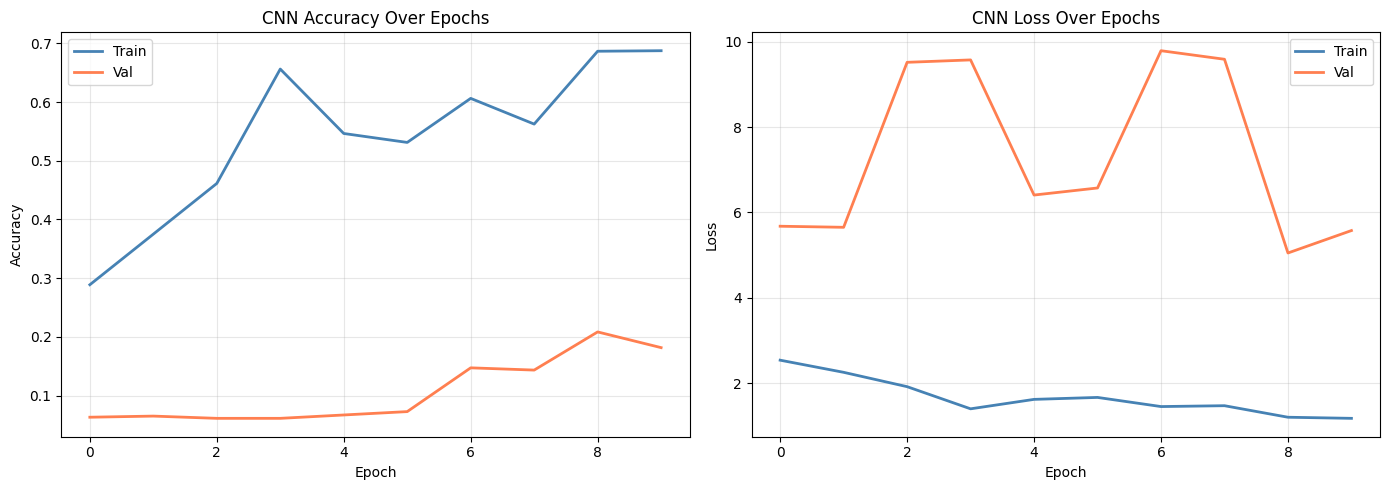

In [ ]:
# plot the training curves to see how the model learned over time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral',      linewidth=2)
axes[0].set_title("CNN Accuracy Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],         label='Train', color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'],     label='Val',   color='coral',      linewidth=2)
axes[1].set_title("CNN Loss Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 7: CNN Hyperparameter Tuning with Keras Tuner

Instead of manually trying different CNN architectures, I'll use Keras Tuner
to automatically search for the best combination of:
- Number of conv blocks
- Filter sizes
- Dropout rates
- Dense layer size
- Learning rate

This is called **Neural Architecture Search** (on a small scale). Pretty cool!


In [ ]:
# install keras-tuner if not already available
try:
    import keras_tuner as kt
    print("keras-tuner already installed")
except ImportError:
    !pip install keras-tuner -q
    import keras_tuner as kt
    print("keras-tuner installed successfully")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.9 MB/s eta 0:00:00
keras-tuner installed successfully


In [ ]:
# define a model-building function where hyperparameters are tunable
def build_tunable_cnn(hp):
    model = models.Sequential()

    # tune: how many conv blocks to use
    num_blocks = hp.Choice('num_blocks', [2, 3])

    # Block 1
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_1', [32, 64]),
        kernel_size=(3,3), activation='relu',
        padding='same', input_shape=(128, 128, 3)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(hp.Float('dropout_1', 0.1, 0.4, step=0.1)))

    # Block 2
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_2', [64, 128]),
        kernel_size=(3,3), activation='relu', padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(hp.Float('dropout_2', 0.1, 0.4, step=0.1)))

    # optional Block 3
    if num_blocks == 3:
        model.add(layers.Conv2D(
            filters=hp.Choice('filters_3', [128, 256]),
            kernel_size=(3,3), activation='relu', padding='same'
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D(2, 2))
        model.add(layers.Dropout(hp.Float('dropout_3', 0.2, 0.5, step=0.1)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(
        units=hp.Choice('dense_units', [128, 256, 512]), activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout_dense', 0.3, 0.6, step=0.1)))
    model.add(layers.Dense(len(classes), activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-3, 5e-4, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Tunable model function defined!")


Tunable model function defined!


In [ ]:
# run the search - trying 8 different configurations
tuner = kt.RandomSearch(
    build_tunable_cnn,
    objective='val_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='kt_dir',
    project_name='plant_disease_cnn',
    overwrite=True
)

print("Starting hyperparameter search (this will take a while)...")
tuner.search(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    steps_per_epoch=len(X_train_cnn) // 32,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=15,
    callbacks=[callbacks.EarlyStopping(monitor='val_accuracy', patience=5)],
    verbose=1
)


Trial 3 Complete [00h 57m 30s]
val_accuracy: 0.6271510720252991

Best val_accuracy So Far: 0.6271510720252991
Total elapsed time: 01h 31m 47s

Search: Running Trial #4

Value             |Best Value So Far |Hyperparameter
3                 |3                 |num_blocks
64                |64                |filters_1
0.4               |0.4               |dropout_1
64                |128               |filters_2
0.1               |0.3               |dropout_2
128               |256               |dense_units
0.3               |0.3               |dropout_dense
0.001             |0.001             |lr
256               |256               |filters_3
0.4               |0.2               |dropout_3

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.4323 - loss: 1.7919 - val_accuracy: 0.0631 - val_loss: 4.7936
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.5625 - loss: 1.3911 - val_accuracy: 0.0631 - val_loss: 4.8828
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 291

In [ ]:
# get the best hyperparameters and show them
best_hp = tuner.get_best_hyperparameters()[0]

print("Best CNN Hyperparameters found:")
print("-" * 35)
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")


In [ ]:
# now train the best architecture properly (for more epochs)
best_cnn = tuner.hypermodel.build(best_hp)

best_cnn_history = best_cnn.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    steps_per_epoch=len(X_train_cnn) // 32,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    callbacks=cnn_callbacks,
    verbose=1
)

_, best_cnn_acc = best_cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\nTuned CNN Test Accuracy: {best_cnn_acc:.4f}  (base CNN was {cnn_acc:.4f})")


---
## Step 8: Full Model Comparison

Now that all models are trained and tuned, let's put them all side by side
and see which one actually performs the best!


In [ ]:
# collect all final results
all_results = {
    "KNN (default)":         knn_acc,
    "KNN (tuned)":           best_knn_acc,
    "Decision Tree":         dt_acc,
    "Random Forest (tuned)": best_rf_acc,
    "SVM (tuned)":           best_svm_acc,
    "MLP":                   mlp_acc,
    "CNN":                   cnn_acc,
    "CNN (tuned)":           best_cnn_acc,
}

print("Final Results — All Models:")
print("=" * 45)
for name, acc in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 40)
    print(f"  {name:<25} {acc:.4f}  {bar}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# colour-code by model type
color_map = {
    "KNN":           "#9b59b6",
    "Decision Tree": "#e67e22",
    "Random Forest": "#e74c3c",
    "SVM":           "#3498db",
    "MLP":           "#f39c12",
    "CNN":           "#2ecc71",
}

colors = []
for k in all_results.keys():
    for model_type, color in color_map.items():
        if model_type in k:
            colors.append(color)
            break

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(all_results.keys(), all_results.values(),
              color=colors, edgecolor='white', linewidth=0.8, width=0.6)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Plant Disease Detection — All Models Comparison", fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)

# add accuracy labels on top of each bar
for bar, acc in zip(bars, all_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f"{acc:.3f}", ha='center', va='bottom',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best_model_name = max(all_results, key=all_results.get)
print(f"\n🏆 Best Model: {best_model_name} — Accuracy: {all_results[best_model_name]:.4f}")


---
## Step 9: Detailed Analysis of Top Models

Let's look at confusion matrices and classification reports for the top 3 models.
A confusion matrix shows exactly where the model is getting confused —
which classes it's mixing up with which other classes.


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

top_3 = sorted(all_results, key=all_results.get, reverse=True)[:3]
print("Top 3 models:", top_3)

# helper to get predictions for any model
def get_preds(model_name):
    if "CNN (tuned)" in model_name:
        return (np.argmax(best_cnn.predict(X_test_cnn, verbose=0), axis=1),
                np.argmax(y_test_cnn, axis=1))
    elif "CNN" in model_name:
        return (np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1),
                np.argmax(y_test_cnn, axis=1))
    elif "KNN (tuned)" in model_name:
        return best_knn.predict(X_test), y_test
    elif "KNN" in model_name:
        return knn.predict(X_test), y_test
    elif "SVM" in model_name:
        return best_svm.predict(X_test), y_test
    elif "Random Forest" in model_name:
        return best_rf.predict(X_test), y_test
    elif "MLP" in model_name:
        return mlp.predict(X_test), y_test
    else:
        return dt.predict(X_test), y_test

# confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model_name in zip(axes, top_3):
    y_pred_raw, y_true_raw = get_preds(model_name)
    cm = confusion_matrix(y_true_raw, y_pred_raw)
    sns.heatmap(cm, ax=ax, cmap='YlOrRd', annot=False, linewidths=0.2)
    ax.set_title(f"{model_name}\nAcc = {all_results[model_name]:.3f}", fontsize=10)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices — Top 3 Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# full classification report for the best model
print(f"Classification Report — {best_model_name}")
print("=" * 60)

y_pred_best, y_true_best = get_preds(best_model_name)
print(classification_report(
    y_true_best, y_pred_best,
    target_names=[c[:30] for c in classes]
))


In [ ]:
# visualise a few wrong predictions to understand model mistakes
y_pred_vis, y_true_vis = get_preds(best_model_name)
wrong_indices = np.where(y_pred_vis != y_true_vis)[0]

print(f"Total wrong predictions: {len(wrong_indices)} out of {len(y_true_vis)}")
print(f"Showing a few misclassified examples:\n")

# if best model is CNN we need to use CNN test set indices
is_cnn = "CNN" in best_model_name

if not is_cnn and len(wrong_indices) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    for i, idx in enumerate(wrong_indices[:8]):
        # find original image index - approximate match through y array
        true_label = y_true_vis[idx]
        pred_label = y_pred_vis[idx]
        sample_idx = np.where(y == true_label)[0][0]
        img_rgb = cv2.cvtColor(X[sample_idx], cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(
            f"True: {classes[true_label][:18]}\nPred: {classes[pred_label][:18]}",
            fontsize=7, color='red'
        )
        axes[i].axis("off")
    plt.suptitle("Some Misclassified Examples", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("(Image display skipped for CNN test set — indices differ from original array)")


---
## Step 10: Save All Models

Saving everything so we can load them later for the UI without retraining.


In [ ]:
import joblib

joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(best_svm, "best_svm_model.pkl")
joblib.dump(best_rf,  "best_rf_model.pkl")
joblib.dump(mlp,      "mlp_model.pkl")
joblib.dump(pca,      "pca_transform.pkl")
joblib.dump(classes,  "classes.pkl")

best_cnn.save("best_cnn_model.h5")
print("All models saved successfully!")
print("\nFiles saved:")
for f in ["best_knn_model.pkl", "best_svm_model.pkl", "best_rf_model.pkl",
          "mlp_model.pkl", "pca_transform.pkl", "classes.pkl", "best_cnn_model.h5"]:
    print(f"  ✓ {f}")


---
## Step 11: Gradio UI — Interactive Plant Disease Detector 🌿

Finally, let's build a simple web UI where you can upload any leaf image
and get a prediction! Gradio makes this super easy and gives you a public
link that works for 72 hours — so you can share it with anyone.

The UI will let you:
- Upload a leaf photo
- Choose which model to use (CNN, SVM, or KNN)
- See the predicted plant + disease and confidence score
- See the top 5 most likely predictions


In [ ]:
# install gradio
try:
    import gradio as gr
    print("gradio already installed")
except ImportError:
    !pip install gradio -q
    import gradio as gr
    print("gradio installed!")


In [ ]:
import joblib
import numpy as np
import cv2
import tensorflow as tf
import gradio as gr

# load everything back
best_cnn_ui = tf.keras.models.load_model("best_cnn_model.h5")
pca_ui      = joblib.load("pca_transform.pkl")
best_svm_ui = joblib.load("best_svm_model.pkl")
best_knn_ui = joblib.load("best_knn_model.pkl")
classes_ui  = joblib.load("classes.pkl")

IMG_SIZE_UI = 128
print("All models loaded, ready for predictions!")


In [ ]:
def predict_plant_disease(image, model_choice):
    """Main prediction function called by the Gradio UI."""

    if image is None:
        return "Please upload an image first!", None

    # convert PIL image to numpy array and handle RGBA
    img = np.array(image)
    if img.ndim == 2:                  # grayscale → RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    if img.shape[-1] == 4:             # RGBA → RGB
        img = img[:, :, :3]

    img_resized = cv2.resize(img, (IMG_SIZE_UI, IMG_SIZE_UI))
    img_norm    = img_resized / 255.0

    # --- CNN path ---
    if model_choice == "CNN (Best)":
        img_input = img_norm.reshape(1, IMG_SIZE_UI, IMG_SIZE_UI, 3)
        probs     = best_cnn_ui.predict(img_input, verbose=0)[0]

    # --- Classical ML path (PCA → model) ---
    else:
        flat     = img_norm.flatten().reshape(1, -1)
        pca_feat = pca_ui.transform(flat)
        if model_choice == "SVM":
            probs = best_svm_ui.predict_proba(pca_feat)[0]
        elif model_choice == "KNN":
            probs = best_knn_ui.predict_proba(pca_feat)[0]
        else:
            probs = best_svm_ui.predict_proba(pca_feat)[0]

    # format output
    pred_idx  = int(np.argmax(probs))
    pred_conf = float(probs[pred_idx])
    top5_idx  = np.argsort(probs)[::-1][:5]
    top5      = {classes_ui[i]: float(probs[i]) for i in top5_idx}

    # parse class name (format is "PlantName___DiseaseName")
    raw_name   = classes_ui[pred_idx]
    parts      = raw_name.split("___")
    plant      = parts[0].replace("_", " ").title() if len(parts) > 0 else raw_name
    disease    = parts[1].replace("_", " ").title() if len(parts) > 1 else "Unknown"
    is_healthy = "healthy" in disease.lower()

    emoji  = "✅" if is_healthy else "⚠️"
    status = "Healthy 🌿" if is_healthy else f"Disease Detected: **{disease}** 🦠"

    result = (
        f"## {emoji} Diagnosis Result\n\n"
        f"**Plant:** {plant}\n\n"
        f"**Status:** {status}\n\n"
        f"**Confidence:** {pred_conf*100:.1f}%\n\n"
        f"**Model used:** {model_choice}"
    )

    return result, top5


In [ ]:
# build the Gradio interface
with gr.Blocks(
    title="Plant Disease Detector",
    theme=gr.themes.Soft(primary_hue="green", secondary_hue="emerald"),
) as demo:

    gr.Markdown("""
    # 🌿 Plant Disease Detection System
    ### Upload a leaf image to detect plant diseases using ML & Deep Learning
    Trained on the PlantVillage dataset with 38 plant disease classes.
    """)

    with gr.Row():
        # left column — inputs
        with gr.Column(scale=1):
            image_input = gr.Image(
                type="pil",
                label="📷 Upload Leaf Image",
                height=280
            )
            model_selector = gr.Dropdown(
                choices=["CNN (Best)", "SVM", "KNN"],
                value="CNN (Best)",
                label="🤖 Choose Model"
            )
            predict_btn = gr.Button(
                "🔍 Detect Disease", variant="primary", size="lg"
            )
            gr.Markdown("""
            **Tips for best results:**
            - Use a clear, well-lit photo
            - Leaf should fill most of the frame
            - CNN gives the highest accuracy
            - Works best with PlantVillage-style images
            """)

        # right column — outputs
        with gr.Column(scale=1):
            result_output = gr.Markdown(
                value="*Upload an image and click Detect Disease to see results.*"
            )
            top5_output = gr.Label(
                num_top_classes=5,
                label="📊 Top 5 Predictions"
            )

    predict_btn.click(
        fn=predict_plant_disease,
        inputs=[image_input, model_selector],
        outputs=[result_output, top5_output]
    )

    gr.Markdown("""
    ---
    ### About This Project
    This project compares traditional ML algorithms (KNN, SVM, Random Forest, MLP)
    with deep learning (CNN) for plant disease detection.
    The CNN was trained with data augmentation and tuned using Keras Tuner.

    | Model | Approach | Notes |
    |-------|----------|-------|
    | CNN (Best) | Deep Learning | Learns features automatically |
    | SVM | Classical ML | Works on PCA features |
    | KNN | Classical ML | Nearest neighbour matching |
    """)

# share=True gives a public URL valid for 72 hours
demo.launch(share=True, debug=False)
